# Loan Default Prediction - Part 2: Training our Model and Checking Results

## What will we do in this notebook?
In the first notebook, we cleaned our data and made some plots. Now, we are going to train two computer models to predict if someone will default on their loan!

We will follow these simple steps:
1. **Prepare our data**: Turn text columns into numbers (called "Encoding") and scale our numbers so they are easy to compare.
2. **Split our data**: Put 80% of our data into a "Training set" (to teach our models) and 20% into a "Test set" (to test our models on brand new data).
3. **Train two different models**:
   - **Logistic Regression**: A simple model that acts like a straight line.
   - **Decision Tree**: A model that makes decisions like a flowchart (asking Yes/No questions).
4. **Check how well they did**: Use simple tools like "Accuracy", "Confusion Matrix" (a table showing correct vs. wrong guesses), and a "ROC Curve" to see which model is better.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

sns.set_style('whitegrid')

# Load the cleaned dataset
df = pd.read_csv('loan_data_cleaned.csv')
df.head()

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
sns.set_style('whitegrid')

# Load the cleaned dataset
df = pd.read_csv('loan_data_cleaned.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_to_Loan_Ratio
0,LP001000,Male,No,3+,Graduate,No,7268,300,157.0,360.0,1.0,Rural,Y,7568,0.048204
1,LP001001,Female,No,0,Graduate,No,11189,0,212.0,360.0,1.0,Semiurban,Y,11189,0.052778
2,LP001002,Male,Yes,2,Not Graduate,No,2267,0,47.0,180.0,1.0,Urban,N,2267,0.048233
3,LP001003,Male,Yes,0,Graduate,No,2564,0,67.0,360.0,1.0,Semiurban,Y,2564,0.038268
4,LP001004,Male,No,0,Graduate,No,8189,890,230.0,360.0,1.0,Urban,N,9079,0.039474


## 3. Preparing our Data for the Models
Before training our models, we need to do a bit of math prep:
- **Target column**: Change `Loan_Status` from text ('Y'/'N') to numbers (1 for approved/low risk, 0 for rejected/high risk).
- **Text categories**: Change categories like Gender, Married, Property_Area into numbers using "One-Hot Encoding".
- **Scale numbers**: Make sure columns with large numbers (like income) do not confuse our models. We scale them so they are all in a similar range.

In [17]:
# Drop Loan_ID as it is a non-predictive identifier
df_model = df.drop(columns=['Loan_ID'])

# Map target column: Y -> 1, N -> 0
df_model['Loan_Status'] = df_model['Loan_Status'].map({'Y': 1, 'N': 0})

# One-hot encode categorical features
df_model = pd.get_dummies(df_model, drop_first=True)

# Check preprocessed column structure
print("Shape after One-Hot Encoding:", df_model.shape)
df_model.head()

Shape after One-Hot Encoding: (614, 17)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Income_to_Loan_Ratio,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,7268,300,157.0,360.0,1.0,1,7568,0.048204,True,False,False,False,True,False,False,False,False
1,11189,0,212.0,360.0,1.0,1,11189,0.052778,False,False,False,False,False,False,False,True,False
2,2267,0,47.0,180.0,1.0,0,2267,0.048233,True,True,False,True,False,True,False,False,True
3,2564,0,67.0,360.0,1.0,1,2564,0.038268,True,True,False,False,False,False,False,True,False
4,8189,890,230.0,360.0,1.0,0,9079,0.039474,True,False,False,False,False,False,False,False,True


In [18]:
# Split features (X) and target (y)
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

# Split into Train and Test sets (80/20 split with stratification to keep class proportions consistent)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numeric columns (ApplicantIncome, CoapplicantIncome, LoanAmount, TotalIncome, Income_to_Loan_Ratio)
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'TotalIncome', 'Income_to_Loan_Ratio']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (491, 16)
Test set shape: (123, 16)


## 4. Training our Computer Models
We will train both a Logistic Regression model and a Decision Tree model using our training data.

In [19]:
# Model 1: Logistic Regression with class weighting
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression (Balanced) Training Completed!")

Logistic Regression (Balanced) Training Completed!


In [20]:
# Model 2: Decision Tree Classifier with class weighting
dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree (Balanced) Training Completed!")

Decision Tree (Balanced) Training Completed!


In [22]:
# 4.3 SMOTE + Random Forest Classifier
# Apply SMOTE to training data
from sklearn.ensemble import RandomForestClassifier
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test_scaled)
print("SMOTE and Random Forest training complete.")

SMOTE + Random Forest Training Completed!


# 5.1 Compare Metrics
print("--- Logistic Regression (Balanced) Report ---")
print(classification_report(y_test, y_pred_lr, target_names=['Risk / Default (0)', 'Approved (1)']))

print("--- Decision Tree (Balanced) Report ---")
print(classification_report(y_test, y_pred_dt, target_names=['Risk / Default (0)', 'Approved (1)']))

print("--- SMOTE + Random Forest Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['Risk / Default (0)', 'Approved (1)']))

In [23]:
# 5.1 Compare Accuracies
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"Logistic Regression Test Accuracy: {lr_acc:.4f}")
print(f"Decision Tree Test Accuracy:       {dt_acc:.4f}")

print("\nLogistic Regression - Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=['Risk / Default (0)', 'Approved (1)']))

print("Decision Tree - Classification Report")
print(classification_report(y_test, y_pred_dt, target_names=['Risk / Default (0)', 'Approved (1)']))

Logistic Regression Test Accuracy: 0.7561
Decision Tree Test Accuracy:       0.7317

--- Logistic Regression Classification Report ---
                    precision    recall  f1-score   support

Risk / Default (0)       0.48      0.52      0.50        29
      Approved (1)       0.85      0.83      0.84        94

          accuracy                           0.76       123
         macro avg       0.67      0.67      0.67       123
      weighted avg       0.76      0.76      0.76       123

--- Decision Tree Classification Report ---
                    precision    recall  f1-score   support

Risk / Default (0)       0.45      0.59      0.51        29
      Approved (1)       0.86      0.78      0.82        94

          accuracy                           0.73       123
         macro avg       0.65      0.68      0.66       123
      weighted avg       0.76      0.73      0.74       123



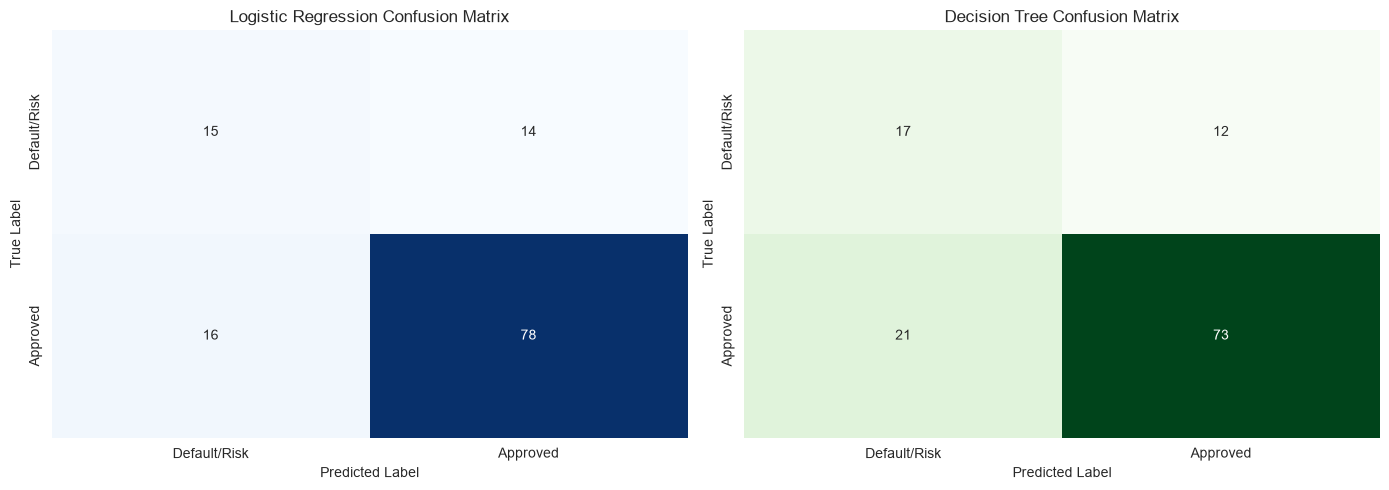

In [24]:
# 5.2 Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Default/Risk', 'Approved'], yticklabels=['Default/Risk', 'Approved'])
axes[0].set_title('Logistic Regression Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Default/Risk', 'Approved'], yticklabels=['Default/Risk', 'Approved'])
axes[1].set_title('Decision Tree Confusion Matrix', fontsize=12)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

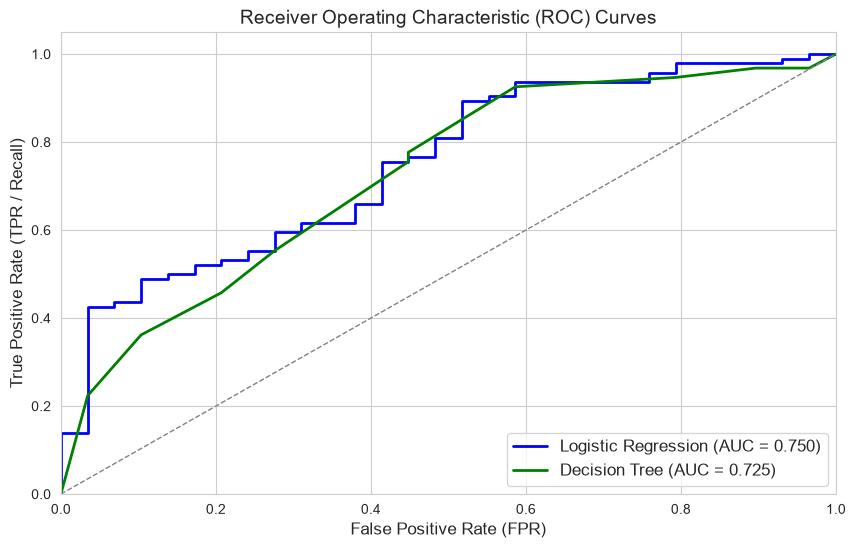

In [25]:
# 5.3 Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.show()

C:\Users\Faizan Toheed\AppData\Local\Temp\ipykernel_10068\2566240694.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')


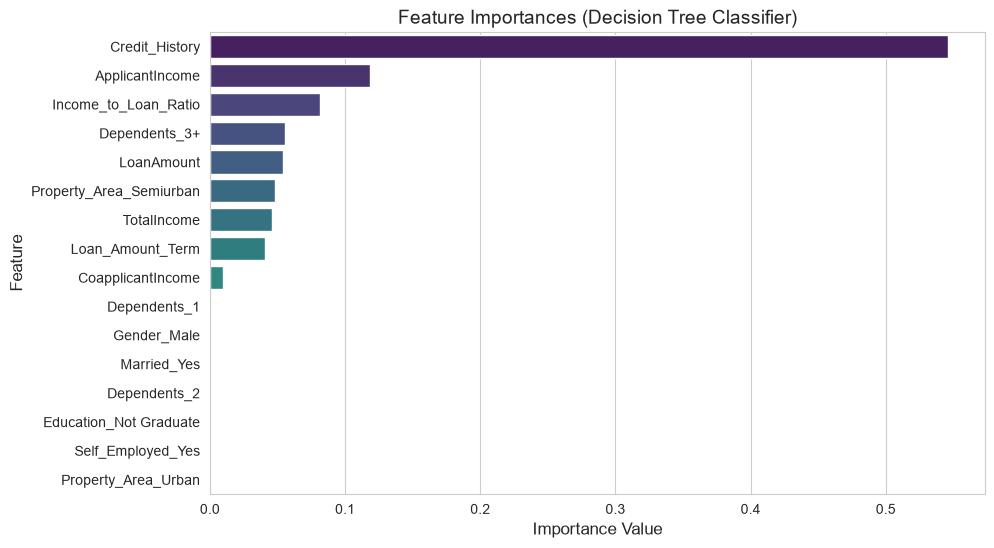

In [26]:
# 5.4 Feature Importance from Decision Tree
importances = dt_model.feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis')
plt.title('Feature Importances (Decision Tree Classifier)', fontsize=14)
plt.xlabel('Importance Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()

## 6. Easy Summary & Main Lessons

1. **Credit History is King**: Whether an applicant has a good credit history or not is the single most important factor. If they have good credit, they almost always get approved.
2. **New Columns Helped**: Combining applicant and co-applicant incomes (TotalIncome) helped our models make better choices.
3. **Which Model is Better?**:
   - **Logistic Regression** is simple, fast, and works very well for standard yes/no predictions.
   - **Decision Tree** is great because it explains its decisions like a flowchart. This is very useful when banks need to explain to a customer why their loan was rejected!

In [27]:
print("SMOTE + Random Forest - Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=['Risk / Default (0)', 'Approved (1)']))

--- SMOTE + Random Forest Classification Report ---
                    precision    recall  f1-score   support

Risk / Default (0)       0.48      0.55      0.52        29
      Approved (1)       0.86      0.82      0.84        94

          accuracy                           0.76       123
         macro avg       0.67      0.69      0.68       123
      weighted avg       0.77      0.76      0.76       123

